# GeminiDecomp — Valutazione Performance Gemini Flash 3

Valuta le performance del modello Gemini Flash 3 sul task di image decomposition del dataset piemmeci_test.
Le metriche (Precision, Recall, F1) vengono calcolate al variare della soglia IoU da 0.1 a 0.95.

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Porta la root del progetto nel path Python
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import (
    GROUND_TRUTH_PATH, PREDICTIONS_PATH,
    CLASSES, IOU_THRESHOLDS, IOU_MAIN, RESULTS_DIR,
)
from src.data_loader import load_ground_truth, load_predictions
from src.metrics import (
    compute_metrics_at_iou,
    compute_metrics_sweep,
    compute_map,
    collect_iou_scores,
)
from src.visualization import (
    plot_metrics_vs_iou,
    plot_summary_heatmap,
    plot_iou_histogram,
    plot_pr_curve,
)

RESULTS_DIR.mkdir(exist_ok=True)
print(f"Project root : {project_root}")
print(f"Results dir  : {RESULTS_DIR}")

Project root : /home/giorgiomelch/VS_Workspace/about_chart_to_table/GeminiDecomp
Results dir  : /home/giorgiomelch/VS_Workspace/about_chart_to_table/GeminiDecomp/results


## 1. Caricamento dati

In [ ]:
gt    = load_ground_truth(GROUND_TRUTH_PATH)
preds = load_predictions(PREDICTIONS_PATH)

n_gt_boxes   = sum(len(v) for v in gt.values())
n_pred_boxes = sum(len(v) for v in preds.values())

print(f"Immagini GT          : {len(gt)}")
print(f"Immagini predizioni  : {len(preds)}")
print(f"Bbox GT totali       : {n_gt_boxes}")
print(f"Bbox predizioni tot. : {n_pred_boxes}")

## 2. Baseline — IoU = 0.5

Riproduce i risultati dell'esperimento originale con soglia fissa a 0.5.

In [3]:
rows = []
for cls in CLASSES + ["all"]:
    target = None if cls == "all" else cls
    m = compute_metrics_at_iou(gt, preds, IOU_MAIN, target_class=target)
    rows.append({"class": cls, **m})

baseline_df = pd.DataFrame(rows)
baseline_df = baseline_df[["class", "precision", "recall", "f1", "tp", "fp", "fn"]]
baseline_df[["precision", "recall", "f1"]] = baseline_df[["precision", "recall", "f1"]].round(4)

print(f"\nMetriche a IoU = {IOU_MAIN}:")
display(baseline_df)


Metriche a IoU = 0.5:


,class,precision,recall,f1,tp,fp,fn
0,chart,0.9629,0.9535,0.9582,2234,86,109
1,non_chart,0.9067,0.8834,0.8949,1584,163,209
2,all,0.9456,0.9371,0.9413,3876,223,260


## 3. Sweep IoU — da 0.1 a 0.95

In [ ]:
from tqdm.notebook import tqdm

print(f"Calcolo metriche per {len(IOU_THRESHOLDS)} soglie IoU × {len(CLASSES)+1} classi...")
sweep_df = compute_metrics_sweep(gt, preds, IOU_THRESHOLDS, CLASSES)

print(f"Righe totali: {len(sweep_df)}  (attese: {len(IOU_THRESHOLDS)} × {len(CLASSES)+1} = {len(IOU_THRESHOLDS)*(len(CLASSES)+1)})")
display(sweep_df.round(4))

## 4. Grafici

Tutti i grafici vengono salvati in `results/`.

### 4.1 Precision / Recall / F1 vs soglia IoU

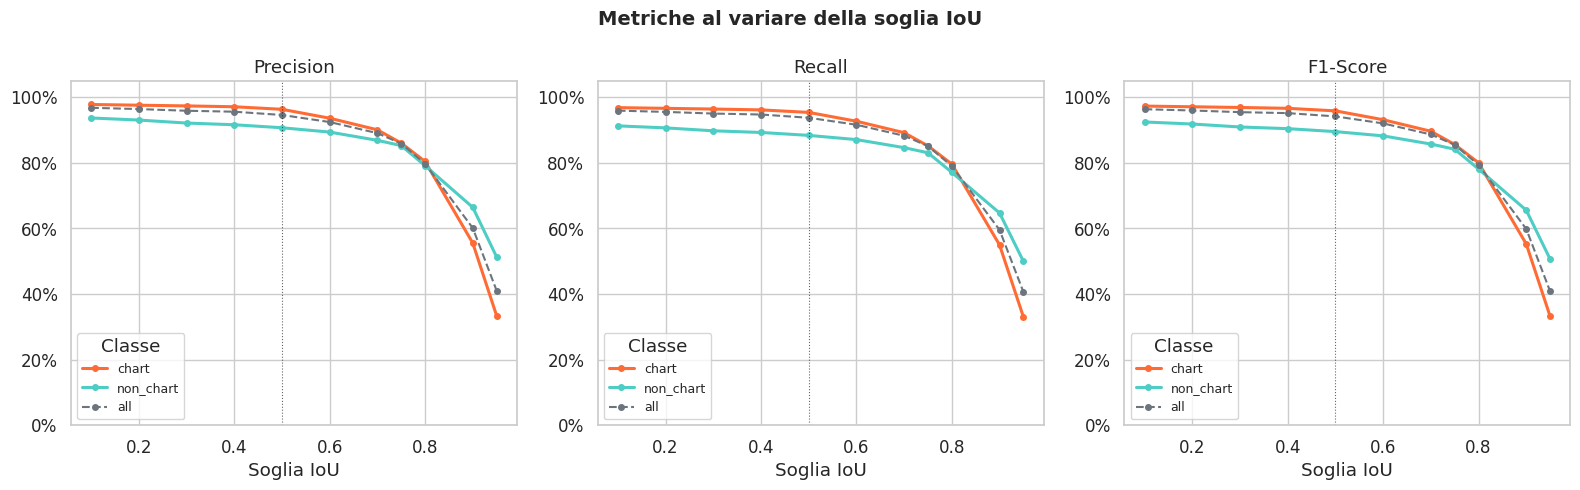

In [5]:
fig = plot_metrics_vs_iou(sweep_df)
plt.show()

### 4.2 Heatmap F1 (classe × soglia IoU)

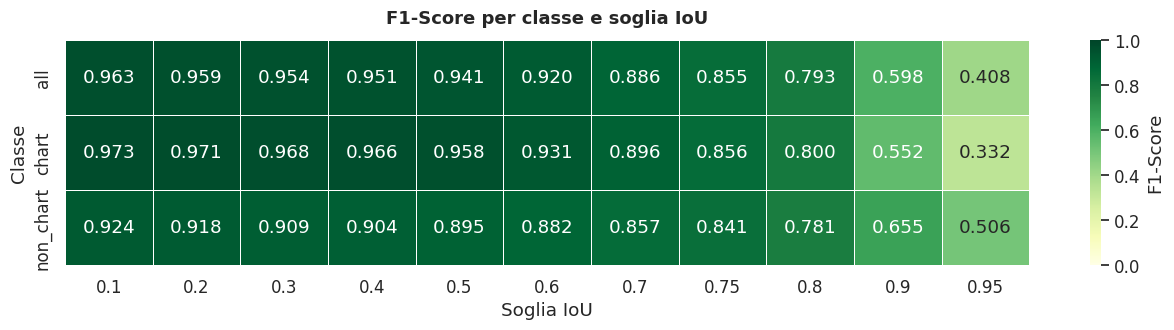

In [6]:
fig = plot_summary_heatmap(sweep_df, metric="f1")
plt.show()

### 4.3 Distribuzione IoU score dei match TP

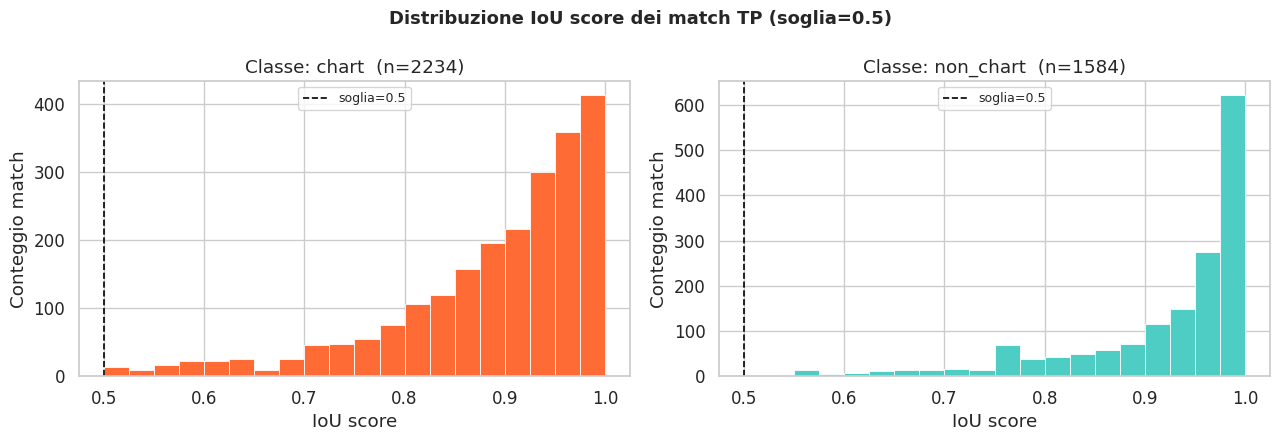

In [7]:
iou_scores = collect_iou_scores(gt, preds, iou_threshold=IOU_MAIN)
fig = plot_iou_histogram(iou_scores, iou_threshold=IOU_MAIN)
plt.show()

### 4.4 Curva Precision-Recall (parametrizzata per soglia IoU)

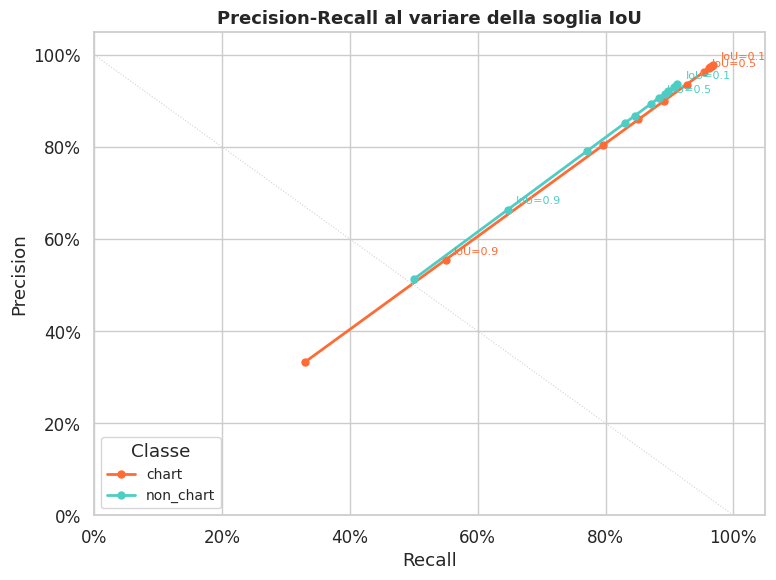

In [8]:
fig = plot_pr_curve(sweep_df)
plt.show()

## 5. Riepilogo — mF1 medio

In [9]:
map_score = compute_map(gt, preds, IOU_THRESHOLDS)
print(f"mF1 @ IoU [{IOU_THRESHOLDS[0]}:{IOU_THRESHOLDS[-1]}] = {map_score:.4f}")
print()

# Tabella riepilogativa per classe principale (IoU=0.5)
print(f"F1 per classe a IoU={IOU_MAIN}:")
for cls in CLASSES:
    row = baseline_df[baseline_df["class"] == cls].iloc[0]
    print(f"  {cls:12s}  P={row['precision']:.4f}  R={row['recall']:.4f}  F1={row['f1']:.4f}")
print(f"  {'all':12s}  P={baseline_df[baseline_df['class']=='all']['precision'].values[0]:.4f}  "
      f"R={baseline_df[baseline_df['class']=='all']['recall'].values[0]:.4f}  "
      f"F1={baseline_df[baseline_df['class']=='all']['f1'].values[0]:.4f}")

mF1 @ IoU [0.1:0.95] = 0.8307

F1 per classe a IoU=0.5:
  chart         P=0.9629  R=0.9535  F1=0.9582
  non_chart     P=0.9067  R=0.8834  F1=0.8949
  all           P=0.9456  R=0.9371  F1=0.9413
